In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import root_mean_squared_error as rmse
import time
import tkinter as tk
from tkinter import messagebox
import math
import matplotlib as mpl
from scipy.spatial import ConvexHull
import os
# our functions
import predict_Beta_I
import choice_start_day
import plot_hyb

import warnings
warnings.filterwarnings(action='ignore')

# to account for updates when files change
%load_ext autoreload
%autoreload 2

In [15]:
seed_dirs='initial_data/new_ba_100000/'
df_seeds = 'initial_data/new_seeds_parameters.csv'
df_seeds = pd.read_csv(df_seeds)

(-1e-07, 1e-05)

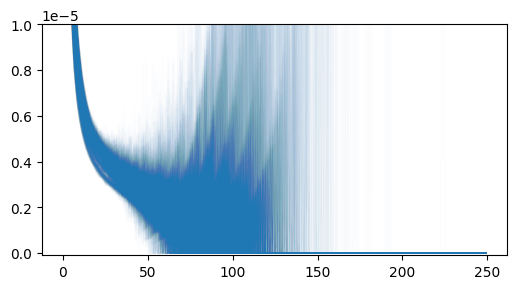

In [20]:
plt.subplots(figsize=(6,3))
seed_numbers = df_seeds[df_seeds['set']=='train']['file'].values

for i in seed_numbers:
    seed_df = pd.read_csv(seed_dirs+i.split('\\')[-1])
    plt.plot(seed_df.Beta, color='tab:blue', alpha=0.01)

plt.ylim(-1e-7,1e-5)


(-1e-07, 1e-05)

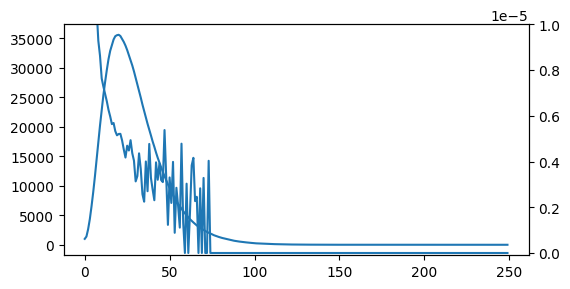

In [30]:
fig, ax = plt.subplots(figsize=(6,3))
ax_b = ax.twinx()
ax.plot(seed_df.I)
ax_b.plot(seed_df.Beta)

ax_b.set_ylim(-1e-7,1e-5)

(-1e-11, 1e-11)

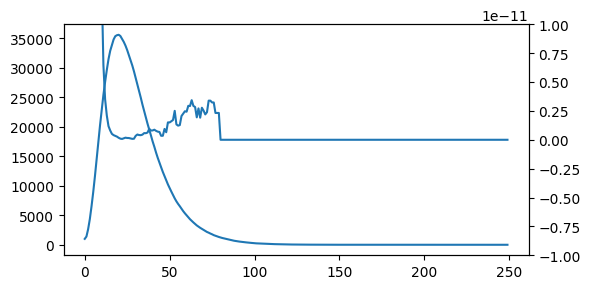

In [31]:
fig, ax = plt.subplots(figsize=(6,3))
ax_b = ax.twinx()
ax.plot(seed_df.I)
ax_b.plot(seed_df.Beta.rolling(7).var())

ax_b.set_ylim(-1e-11,1e-11)

(-1e-11, 1e-11)

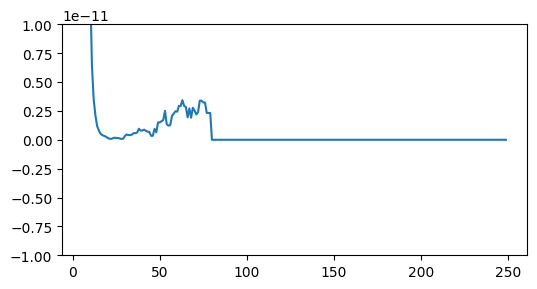

In [28]:
plt.subplots(figsize=(6,3))
plt.plot(seed_df.Beta.rolling(7).var())
plt.ylim(-1e-11,1e-11)

In [32]:
from sklearn.preprocessing import MinMaxScaler

In [56]:
scaler = MinMaxScaler()

var_vals = seed_df.Beta.rolling(7).var()
scaled_varv = scaler.fit_transform(var_vals.values.reshape(-1, 1))

fraq = 0.1
full_pop = seed_df.iloc[0,:4].sum()
n_people = full_pop*fraq

thresh = 0.01
day_with_npeople = seed_df[seed_df.I >= full_pop*fraq].index[0]
cpoint = np.nanmin(np.where(scaled_varv[day_with_npeople:] < thresh)[0])

cpoint, day_with_npeople

(np.int64(5), np.int64(6))

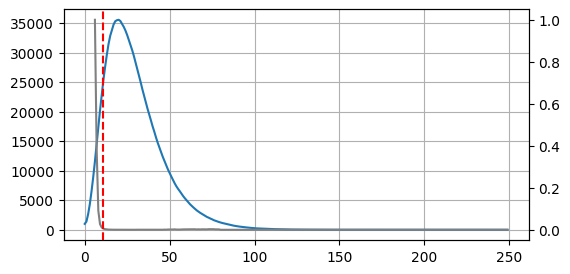

In [65]:
fig, ax = plt.subplots(figsize=(6,3))
ax_b = ax.twinx()
ax.plot(seed_df.I)
ax_b.plot(scaled_varv, color='gray')

#ax_b.set_ylim(-1e-12,1e-11)

plt.axvline(cpoint + day_with_npeople, ls='--', color='red')
ax.grid()

In [74]:
full_pop*0.1

np.float64(10000.0)

In [75]:
full_pop = seed_df.iloc[0,:4].sum()
I_clm = seed_df.columns[2]
n_people = full_pop*0.2

switch = seed_df[seed_df[I_clm]>=n_people]
switch.index[0]

np.int64(9)

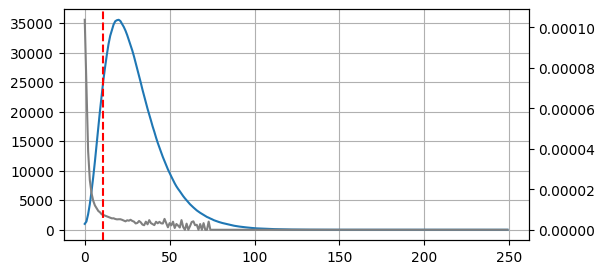

In [66]:
fig, ax = plt.subplots(figsize=(6,3))
ax_b = ax.twinx()
ax.plot(seed_df.I)
ax_b.plot(seed_df.Beta, color='gray')

#ax_b.set_ylim(-1e-12,1e-11)

plt.axvline(cpoint + day_with_npeople, ls='--', color='red')
ax.grid()

In [ ]:
dire = "../new_sw_100000/"
sw = pd.read_csv('test_files.csv').iloc[::100].values

fig, ax = plt.subplots(1,1, figsize=(6,3))
ax_b = ax.twinx()
for file in sw:
    df = pd.read_csv(dire+file[0], usecols=['I','Beta'])
    ax.plot(df.I,color='tab:blue', alpha=0.2)
    ax_b.plot(df.Beta,color='gray', alpha=0.05)

ax_b.set_ylim(-5e-6,1e-4)
ax.grid()

## !

In [6]:
def apply_methods(seed_dirs='initial_data/initial_data_ba_10000/',
                  seed_numbers=[], on_incidence=False, 
                 idx_s=0, idx_e=11, show_fig_flag=False,
                 is_filename=False, sigma=0.1, gamma=0.08, perc_switch=0.01,
                 suff_m='sw100k', suff='sw100k'):
    
    #df_seeds = pd.read_csv(df_seeds)
    if is_filename:
        col = 'file'
    else:
        col='seed_number'
        
    #seed_numbers = df_seeds[df_seeds.set=='test'][col].values[:n_seeds]

    types_start_day = ['fraq_people']#, 'roll_var', 'roll_var_seq']

    methods = ['last value','expanding mean last value',
               'median beta', 
               #'regression (day)',
               'regression beta', #'arimax',
               'lstm'
              ]

    new_labels = ['last_value', 'expanding_mean_last_value', 

            'median_beta', #'regression_day',
            'regression_beta', #'arimax',
                  'lstm_day_E_previous_I'
                 ]

    for type_start_day in types_start_day:

        for beta_pred,new_label in zip(methods[idx_s:idx_e], 
                                       new_labels[idx_s:idx_e]):

            if 'median' in beta_pred:
                model_path = f'{suff_m}_median_beta.csv'
            elif 'regression beta' in  beta_pred: 
                model_path = f'{suff_m}_regression_bt.joblib'
            #elif 'arimax' in beta_pred: 
            #    model_path = f'{seed_dirs}/regression_day_for_seir.joblib'
            elif 'lstm' in beta_pred:
                model_path = f'{suff_m}_lstm_4_001_full'    
            else:
                model_path=''
            print('path: ', model_path)
            
            try:
                all_rmse_I, all_rmse_Inc, all_rmse_Beta, \
                    all_r2, all_r2_Inc, all_peak, \
                    execution_time, start_days = plot_hyb.main_f(I_prediction_method='seir', 
                                        stochastic=False, count_stoch_line=0, 
                                        beta_prediction_method=beta_pred, 
                                        type_start_day=type_start_day, 
                                        seed_numbers=seed_numbers, 
                                        show_fig_flag=show_fig_flag,
                                        seed_dirs=seed_dirs, 
                                        sigma=sigma, gamma=gamma, 
                                        ax=None, model_path=model_path,
                                        perc_switch=perc_switch,
                                        is_filename=is_filename,
                                        on_incidence=on_incidence)
                
                # creating a dataframe for peaks
                all_peak = pd.DataFrame(all_peak, 
                                columns=['actual_peak_I', 'predicted_peak_I', 
                                        'actual_peak_Inc', 'predicted_peak_inc',
                                        'actual_peak_day', 'predicted_peak_day',
                                        'actual_peak_day_Inc', 'predicted_peak_day_inc'])
                # creating a dataframe for peaks RMSE, predicted time, start day
                rmse_df = pd.DataFrame({
                    'rmse_I': all_rmse_I,
                    'rmse_Inc': all_rmse_Inc,
                    'rmse_Beta': all_rmse_Beta,
                    'r2': all_r2,
                    'r2_Inc': all_r2_Inc,
                    'time_predict': execution_time,
                    f'{type_start_day}': start_days})

                # merging dataframes
                results = pd.concat([rmse_df, all_peak], axis=1)
                folder_name = seed_dirs.split('/')[-2]
                
            except FileNotFoundError:
                pass
                
            if not show_fig_flag:
                path = f'results/{folder_name}/{type_start_day}/'
                if not os.path.exists(path):
                    os.makedirs(path)
                results.to_csv(f'{path}/{new_label}_results_{suff}.csv', 
                           index=False)
                

In [6]:
sw.shape

(24000, 1)

In [8]:
sw = pd.read_csv('ba_test_files.csv').values

In [15]:
sw[::10][:2]

array([['p_0.1_0.3_0.2_0.0001_0.2800000000000001_seed_0.csv'],
       ['p_0.1_0.3_0.2_0.0001_0.3200000000000001_seed_0.csv']],
      dtype=object)

path:  
last value
path:  
expanding mean last value
path:  ba100k_median_beta.csv
median beta
path:  ba100k_regression_bt.joblib
regression beta


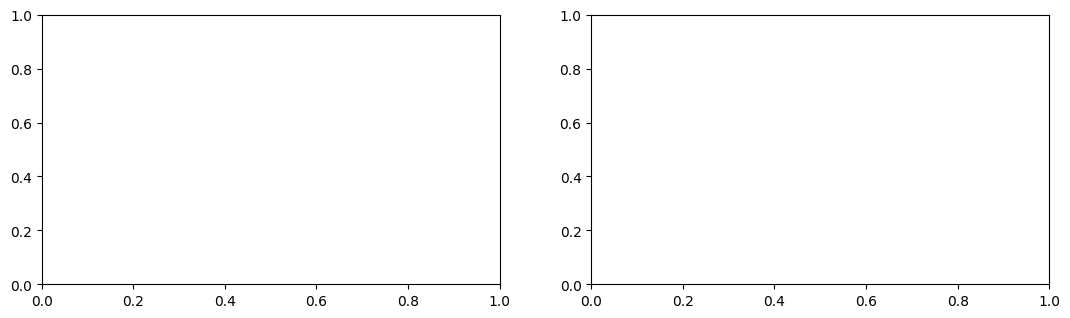

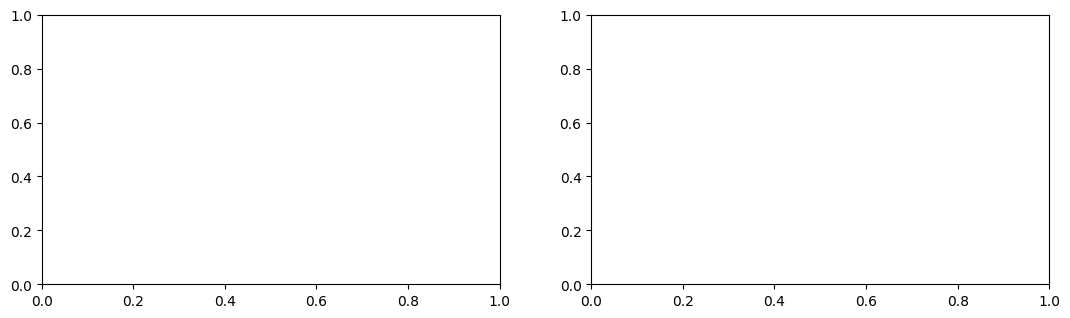

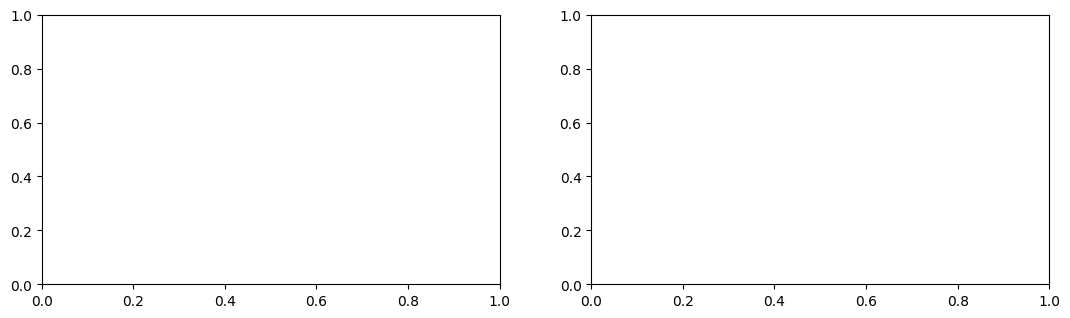

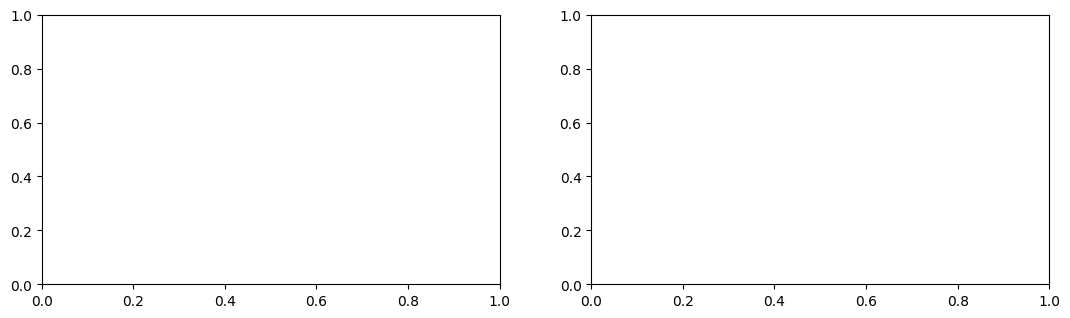

In [14]:
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[::10][:2], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=True,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.01,
             suff_m='ba100k', suff='ba100k_10')

In [5]:
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, perc_switch=0.01,
             suff_m='ba100k', suff='ba100k_10')

path:  
last value
path:  
expanding mean last value
path:  ba100k_median_beta.csv
median beta
path:  ba100k_regression_bt.joblib
regression beta


In [6]:
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, perc_switch=0.011,
             suff_m='ba100k', suff='ba100k_11')

path:  
last value
path:  
expanding mean last value
path:  ba100k_median_beta.csv
median beta
path:  ba100k_regression_bt.joblib
regression beta


In [7]:
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, perc_switch=0.015,
             suff_m='ba100k', suff='ba100k_15')

path:  
last value
path:  
expanding mean last value
path:  ba100k_median_beta.csv
median beta
path:  ba100k_regression_bt.joblib
regression beta


## sw

path:  
last value


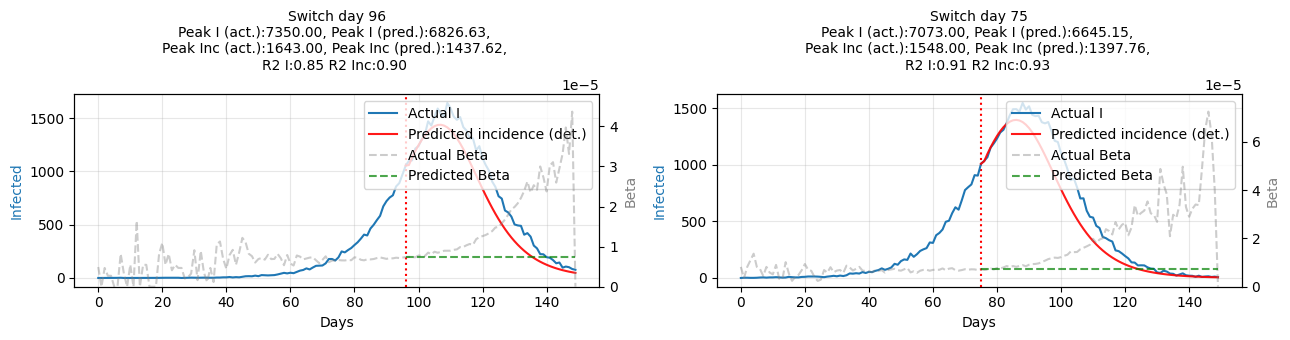

path:  
expanding mean last value


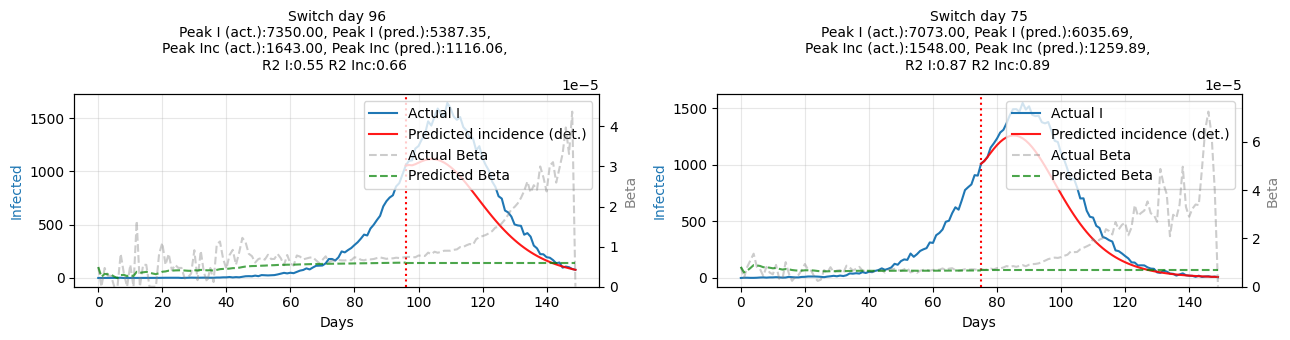

path:  sw100k_median_beta.csv
median beta


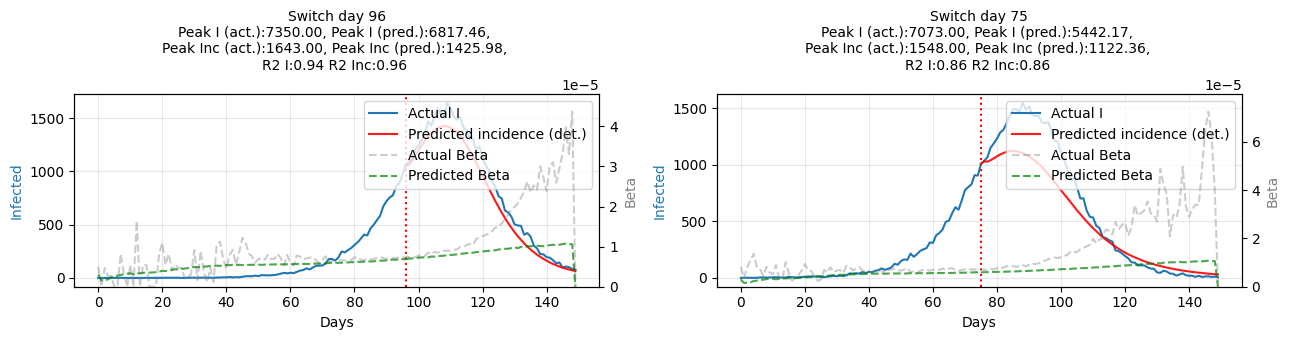

path:  sw100k_regression_bt.joblib
regression beta


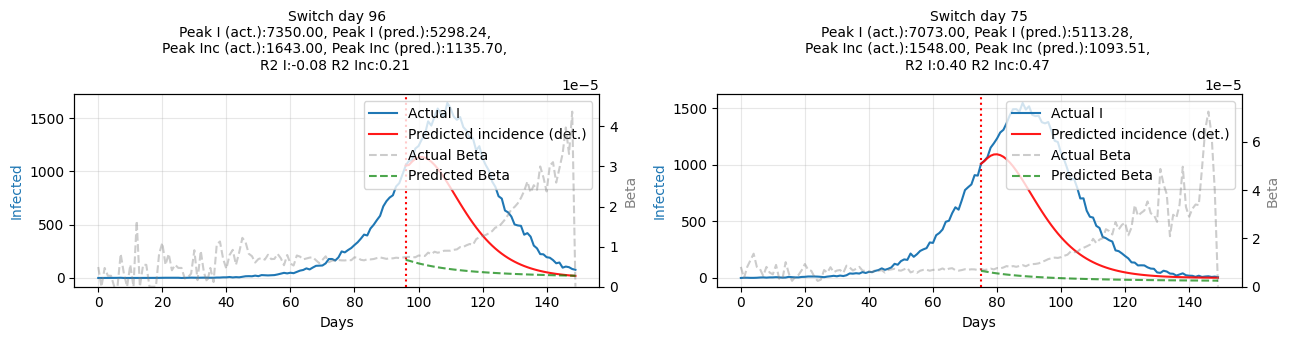

path:  sw100k_lstm_4_001_full
lstm


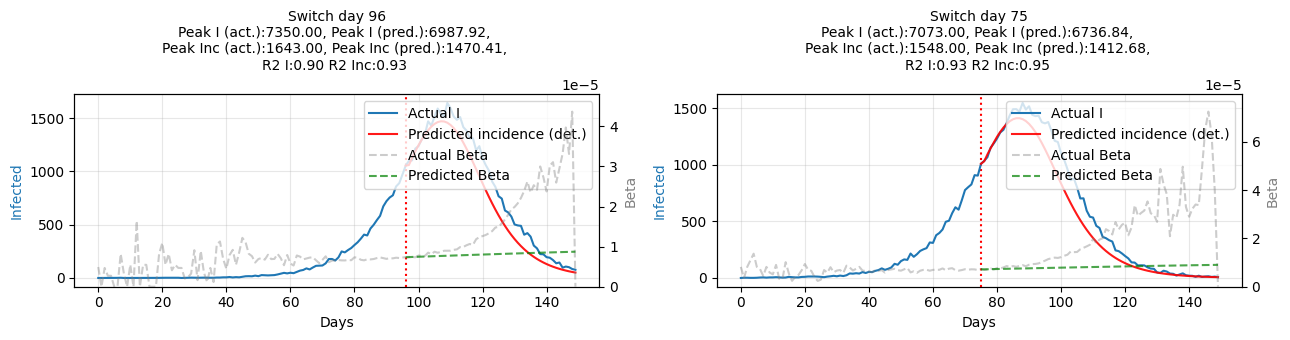

In [3]:
sw = pd.read_csv('test_files.csv').values
k = 22000
apply_methods(seed_dirs="../new_sw_100000/",
              seed_numbers=sw[k:k+2], on_incidence=True,
              idx_s=0, idx_e=5, show_fig_flag=True,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.01,
             suff_m='sw100k')

In [4]:
sw = pd.read_csv('test_files.csv').values
apply_methods(seed_dirs="../new_sw_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.0005,
             suff_m='sw100k', suff='_inc_05')

path:  
last value
path:  
expanding mean last value
path:  sw100k_median_beta.csv
median beta
path:  sw100k_regression_bt.joblib
regression beta


In [5]:
sw = pd.read_csv('test_files.csv').values
apply_methods(seed_dirs="../new_sw_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.00075,
             suff_m='sw100k', suff='_inc_075')

path:  
last value
path:  
expanding mean last value
path:  sw100k_median_beta.csv
median beta
path:  sw100k_regression_bt.joblib
regression beta


In [6]:
sw = pd.read_csv('test_files.csv').values
apply_methods(seed_dirs="../new_sw_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.01,
             suff_m='sw100k', suff='_inc_1')

path:  
last value
path:  
expanding mean last value
path:  sw100k_median_beta.csv
median beta
path:  sw100k_regression_bt.joblib
regression beta


In [7]:
sw = pd.read_csv('test_files.csv').values
apply_methods(seed_dirs="../new_sw_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.0125,
             suff_m='sw100k', suff='_inc_125')

path:  
last value
path:  
expanding mean last value
path:  sw100k_median_beta.csv
median beta
path:  sw100k_regression_bt.joblib
regression beta


In [8]:
sw = pd.read_csv('test_files.csv').values
apply_methods(seed_dirs="../new_sw_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.015,
             suff_m='sw100k', suff='_inc_15')

path:  
last value
path:  
expanding mean last value
path:  sw100k_median_beta.csv
median beta
path:  sw100k_regression_bt.joblib
regression beta
